In [37]:
import os
import pickle
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, RoFormerModel, pipeline

# --- Configuration ---
RECOMPUTE = False 
CACHE_FILE = "avid_embeddings_checkpoint.pkl"
# Define the repository and the specific filename within it
DATASETS_CONFIG = {
    "COGNANO/AVIDa-hTNFa": "AVIDa-hTNFa.csv",
    "COGNANO/AVIDa-hIL6": "AVIDa-hIL6.csv",
    "COGNANO/AVIDa-SARS-CoV-2": "AVIDa-SARS-CoV-2.csv"
}
SAMPLE_SIZE = 250 

device = 0 if torch.cuda.is_available() else -1

# --- Logic for Checkpointing ---
if not RECOMPUTE and os.path.exists(CACHE_FILE):
    print(f"Loading cached embeddings from {CACHE_FILE}...")
    with open(CACHE_FILE, "rb") as f:
        all_results = pickle.load(f)
else:
    # Initialize models only if we need to compute
    print("Loading Language Models...")
    ab2_tokenizer = AutoTokenizer.from_pretrained("alchemab/antiberta2", trust_remote_code=True, use_fast=False)
    ab2_model = RoFormerModel.from_pretrained("alchemab/antiberta2", trust_remote_code=True).to("cuda" if device==0 else "cpu")
    h3_pipe = pipeline("feature-extraction", model="Chrode/H3BERTa", device=device)

    all_results = {}
    
    for repo_id, filename in DATASETS_CONFIG.items():
        print(f"\n--- Processing {repo_id} ---")
        
        # FIX: Point exactly to the data file to avoid column mismatch errors
        ds = load_dataset(repo_id, data_files=filename, split="train")
        df = pd.DataFrame(ds)
        
        # 1. Balanced Subsampling
        df_b = df[df['label'] == 1].sample(n=min(SAMPLE_SIZE, len(df[df['label']==1])), random_state=42)
        df_nb = df[df['label'] == 0].sample(n=min(SAMPLE_SIZE, len(df[df['label']==0])), random_state=42)
        df_sub = pd.concat([df_b, df_nb]).reset_index(drop=True)
        
        # 2. Extract CDR-H3
        print("Extracting CDR-H3 regions...")
        df_sub['cdr_h3'] = df_sub['VHH_sequence'].apply(get_vhh_cdr3)
        df_sub = df_sub.dropna(subset=['cdr_h3']).reset_index(drop=True)
        
        # 3. Full Length (AntiBERTa2)
        print(f"Embedding Full VHH ({len(df_sub)} seqs)...")
        x_full = np.array([get_ab2_emb(s) for s in tqdm(df_sub['VHH_sequence'], leave=False)])
        
        # 4. CDR-H3 (H3BERTa) - Batching for speed
        print(f"Embedding CDR-H3 ({len(df_sub)} seqs)...")
        # We pass the list directly to the pipeline for batch optimization
        raw_h3_embs = h3_pipe(df_sub['cdr_h3'].tolist())
        # H3BERTa Mean Pooling (mean across the token dimension)
        x_cdr = np.array([np.array(o[0]).mean(axis=0) for o in raw_h3_embs])
        
        all_results[repo_id] = {
            'X_full': x_full,
            'X_cdr': x_cdr,
            'y': df_sub['label'].values
        }

    # Save to disk
    with open(CACHE_FILE, "wb") as f:
        pickle.dump(all_results, f)
    print(f"\nAll embeddings saved to {CACHE_FILE}")

Loading Language Models...


Some weights of RobertaModel were not initialized from the model checkpoint at Chrode/H3BERTa and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu



--- Processing COGNANO/AVIDa-hTNFa ---


Generating train split: 0 examples [00:00, ? examples/s]

Extracting CDR-H3 regions...
Embedding Full VHH (500 seqs)...


...

README.md: 0.00B [00:00, ?B/s]

AVIDa-SARS-CoV-2.csv:   0%|          | 0.00/13.8M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Extracting CDR-H3 regions...
Embedding Full VHH (500 seqs)...


Embedding CDR-H3 (500 seqs)...

All embeddings saved to avid_embeddings_checkpoint.pkl


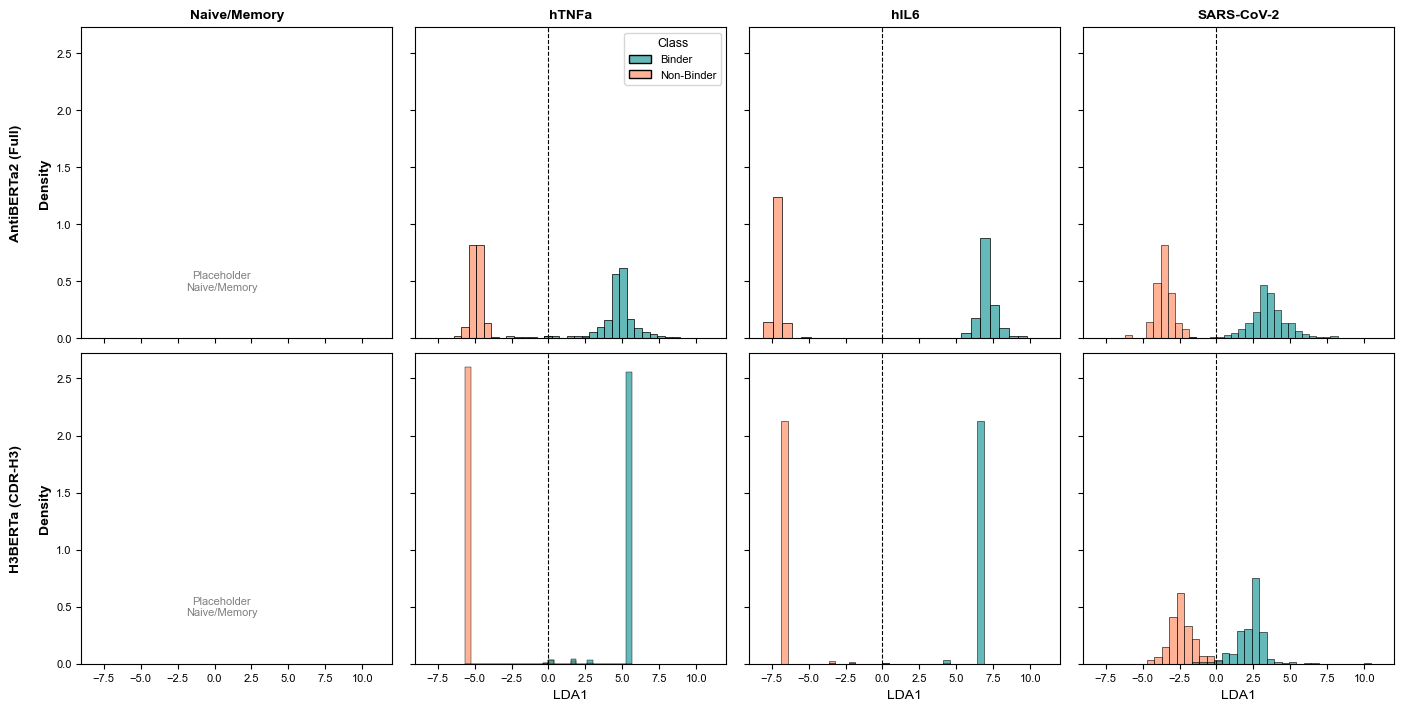

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# 1. Plotting Configuration
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.constrained_layout.use": True,
    "font.family": "sans-serif"
})

# Define grid structure
antigens = ["Naive/Memory", "hTNFa", "hIL6", "SARS-CoV-2"]
models = ["AntiBERTa2 (Full)", "H3BERTa (CDR-H3)"]
dataset_keys = [None, "COGNANO/AVIDa-hTNFa", "COGNANO/AVIDa-hIL6", "COGNANO/AVIDa-SARS-CoV-2"]

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharex=True, sharey=True)

# 2. Iterate through Rows (Models) and Columns (Antigens)
for r_idx, model_label in enumerate(models):
    for c_idx, ant_name in enumerate(antigens):
        ax = axes[r_idx, c_idx]
        ax.set_box_aspect(1) # Ensure square plots
        
        # --- Handle Column 0 (Placeholder) ---
        if c_idx == 0:
            ax.text(0.5, 0.5, f"Placeholder\n{ant_name}", ha='center', va='center', color='gray', fontsize=8)
            if r_idx == 0: ax.set_title(ant_name, fontweight='bold')
            if c_idx == 0: ax.set_ylabel(f"{model_label}\n\nDensity", fontweight='bold')
            continue

        # --- Load and Process Data ---
        ds_key = dataset_keys[c_idx]
        data = all_results[ds_key]
        
        # Select embedding based on row
        X = data['X_full'] if r_idx == 0 else data['X_cdr']
        y = data['y']
        
        # Run LDA
        lda = LDA()
        X_lda = lda.fit_transform(X, y).flatten()
        
        # Create temp DF for seaborn
        df_plot = pd.DataFrame({'LDA1': X_lda, 'Class': ['Binder' if i == 1 else 'Non-Binder' for i in y]})

        # --- Plotting ---
        sns.histplot(
            data=df_plot, x='LDA1', hue='Class', element='bars',
            stat='density', common_norm=False, multiple='layer',
            palette={'Binder': '#008B8B', 'Non-Binder': '#FF7F50'}, # Teal and Coral
            alpha=0.6, bins=30, ax=ax, legend=(r_idx == 0 and c_idx == 1)
        )
        
        # --- Scientific Styling ---
        ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
        
        # Column Titles (Top Row only)
        if r_idx == 0:
            ax.set_title(ant_name, fontweight='bold')
            
        # Row Labels (Left Column only)
        if c_idx == 0:
            ax.set_ylabel(f"{model_label}\n\nDensity", fontweight='bold')
        else:
            ax.set_ylabel("")

        # X-Axis Labels (Bottom Row only)
        if r_idx == 1:
            ax.set_xlabel("LDA1")
        else:
            ax.set_xlabel("")

# 3. Final Export
plt.savefig("VHH_Antigen_LDA_Comparison.svg", format='svg', bbox_inches='tight')
plt.show()